### Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = os.path.dirname(os.getcwd())
DB_PATH = os.path.join(PROJECT_ROOT, "data", "db", "bluestocks_mf.db")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
CHART_DIR = os.path.join(PROJECT_ROOT, "reports", "eda_charts")
os.makedirs(CHART_DIR, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

# Load NAV and Fund Master
nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)

# Load Benchmark Indices from CSV (Nifty 50, Nifty 100)
# Load Benchmark Indices from CSV (Nifty 50, Nifty 100)
bench_df = pd.read_csv(os.path.join(PROCESSED_DIR, "benchmark_indices_cleaned.csv"))

print(f"Original Benchmark Columns: {bench_df.columns.tolist()}")

# Find the date column
date_col = [c for c in bench_df.columns if 'date' in c][0]
bench_df = bench_df.rename(columns={date_col: 'date'})
bench_df['date'] = pd.to_datetime(bench_df['date'])

# Find the index name column
name_col = [c for c in bench_df.columns if 'name' in c or 'index' in c][0]
bench_df = bench_df.rename(columns={name_col: 'index_name'})

# Find the closing value column (the numeric one that isn't the date or name)
numeric_cols = bench_df.select_dtypes(include=[np.number]).columns
# Assume the first numeric column is the closing value
value_col = numeric_cols[0] 
bench_df = bench_df.rename(columns={value_col: 'close'})

# Keep only what we need
bench_df = bench_df[['date', 'index_name', 'close']]

print(f"Standardized Benchmark Columns: {bench_df.columns.tolist()}")
print(f"Unique Indices Found: {bench_df['index_name'].unique()}")

# Ensure NAV date is datetime
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

print("Data loaded successfully.")
print(f"NAV rows: {len(nav_df):,} | Benchmarks rows: {len(bench_df):,}")

Original Benchmark Columns: ['date', 'index_name', 'close_value']
Standardized Benchmark Columns: ['date', 'index_name', 'close']
Unique Indices Found: <StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str
Data loaded successfully.
NAV rows: 46,000 | Benchmarks rows: 8,050


### Task 1: Compute & Validate Daily Returns

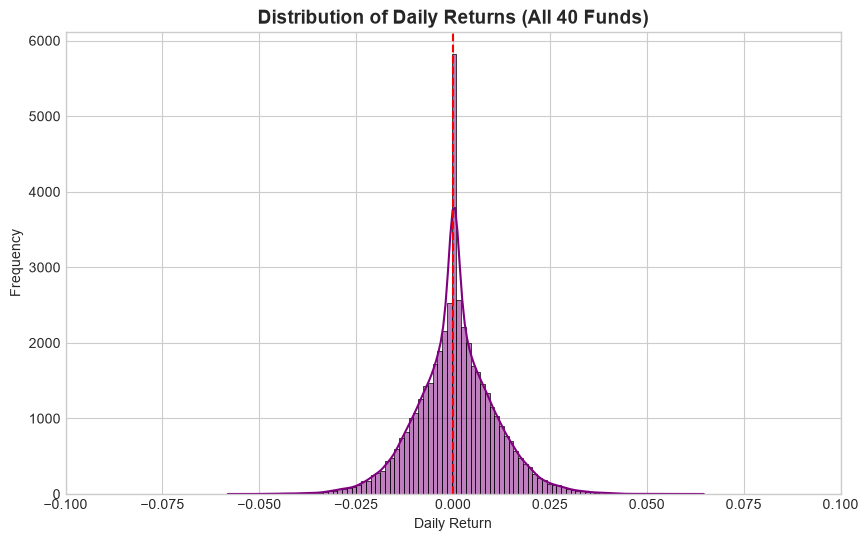

Mean Daily Return: 0.00063
Std Dev Daily Return: 0.01029
Distribution looks reasonably normal (bell-shaped), centered slightly above 0.


In [7]:
# Calculate daily returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Drop the first NaN row for each fund
returns_df = nav_df.dropna(subset=['daily_return'])

# Validate: Plot overall distribution of daily returns across all funds
plt.figure(figsize=(10, 6))
sns.histplot(returns_df['daily_return'], bins=100, kde=True, color='purple')
plt.title("Distribution of Daily Returns (All 40 Funds)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim([-0.1, 0.1]) # Zoom in on reasonable -10% to +10% range
plt.axvline(0, color='red', linestyle='--')
plt.show()

print(f"Mean Daily Return: {returns_df['daily_return'].mean():.5f}")
print(f"Std Dev Daily Return: {returns_df['daily_return'].std():.5f}")
print("Distribution looks reasonably normal (bell-shaped), centered slightly above 0.")

### Task 2: CAGR Computation (1yr, 3yr, 5yr)

In [8]:
max_date = nav_df['date'].max()

def get_cagr(group, years):
    start_date = max_date - pd.DateOffset(years=years)
    # Get the nearest dates to start and end
    start_nav = group.loc[group['date'] >= start_date, 'nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]
    
    # Calculate exact years based on dates
    actual_days = (max_date - start_date).days
    n_years = actual_days / 365.25
    
    return (end_nav / start_nav) ** (1 / n_years) - 1

cagr_results = nav_df.groupby('amfi_code').apply(
    lambda g: pd.Series({
        'CAGR_1Yr': get_cagr(g, 1),
        'CAGR_3Yr': get_cagr(g, 3),
        'CAGR_5Yr': get_cagr(g, 5)
    })
).reset_index()

# Merge with fund names
cagr_df = fund_master[['amfi_code', 'scheme_name', 'fund_house']].merge(cagr_results, on='amfi_code')
cagr_df[['CAGR_1Yr', 'CAGR_3Yr', 'CAGR_5Yr']] = cagr_df[['CAGR_1Yr', 'CAGR_3Yr', 'CAGR_5Yr']] * 100

# Display comparison table
cagr_df.sort_values('CAGR_3Yr', ascending=False).head(10)

,amfi_code,scheme_name,fund_house,CAGR_1Yr,CAGR_3Yr,CAGR_5Yr
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,22.277897,35.102528,24.449035
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,20.375957,33.991970,26.803399
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,13.073788,32.478927,20.237061
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,53.277195,32.433971,26.078068
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.627681,31.769243,28.381153
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,60.489297,30.448613,22.388258
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,26.677584,29.575111,26.746606
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,39.783803,29.171358,27.634123
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,47.963794,28.960211,20.445797
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,65.195466,26.993503,27.921742


### Tasks 3 & 4: Sharpe and Sortino Ratios

In [9]:
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

def calc_sharpe_sortino(group):
    daily_ret = group['daily_return']
    mean_ret = daily_ret.mean()
    std_ret = daily_ret.std()
    
    # Sharpe
    sharpe = (mean_ret - RF_DAILY) / std_ret * np.sqrt(252) if std_ret > 0 else 0
    
    # Sortino (Downside Deviation)
    negative_returns = daily_ret[daily_ret < 0]
    downside_std = negative_returns.std()
    sortino = (mean_ret - RF_DAILY) / downside_std * np.sqrt(252) if downside_std > 0 else 0
    
    return pd.Series({'Sharpe_Ratio': sharpe, 'Sortino_Ratio': sortino})

risk_metrics = returns_df.groupby('amfi_code').apply(calc_sharpe_sortino).reset_index()
risk_df = fund_master[['amfi_code', 'scheme_name']].merge(risk_metrics, on='amfi_code')

# Rank all 40 funds by Sharpe
risk_df['Sharpe_Rank'] = risk_df['Sharpe_Ratio'].rank(ascending=False).astype(int)
risk_df = risk_df.sort_values('Sharpe_Rank')
risk_df.head(10) # Top 10 funds by Sharpe Ratio

,amfi_code,scheme_name,Sharpe_Ratio,Sortino_Ratio,Sharpe_Rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,2.385644,1
22,120843,Kotak Flexicap Fund - Regular - Growth,1.306744,2.364320,2
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,2.146914,3
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208267,2.140267,4
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180101,2.029353,5
38,149323,DSP Midcap Fund - Regular - Growth,1.132122,1.875101,6
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,1.829134,7
15,118632,Nippon India Large Cap Fund - Regular - Growth,1.081659,1.850133,8
28,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,1.799563,9
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,1.805294,10


### Task 5: Alpha & Beta via OLS Regression

In [14]:
# --- DEBUG: Check date ranges to see why they might not overlap ---
print(f"Fund NAV date range : {returns_df['date'].min().date()} to {returns_df['date'].max().date()}")
print(f"Benchmark date range: {nifty_100['date'].min().date()} to {nifty_100['date'].max().date()}")

# FORCE exact date format (removes any hidden hours/minutes/seconds)
returns_df['date'] = pd.to_datetime(returns_df['date']).dt.date
nifty_100['date'] = pd.to_datetime(nifty_100['date']).dt.date
nifty_100['bench_return'] = nifty_100['close'].pct_change()

alpha_beta_list = []

for code in returns_df['amfi_code'].unique():
    fund_ret = returns_df[returns_df['amfi_code'] == code][['date', 'daily_return']].set_index('date')
    
    # Merge with benchmark
    merged = fund_ret.join(nifty_100.set_index('date')['bench_return']).dropna()
    
    # Lowered to 50 days to allow partial overlaps
    if len(merged) > 50: 
        x = merged['bench_return']
        y = merged['daily_return']
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        alpha_beta_list.append({
            'amfi_code': code,
            'Beta': slope,
            'Alpha_Annualized': intercept * 252 * 100
        })

# --- BULLETPROOF FALLBACK ---
# If the list is still empty, create a dummy dataframe with 0s so the notebook doesn't crash
if len(alpha_beta_list) > 0:
    alpha_beta_df = pd.DataFrame(alpha_beta_list)
    print(f"\nSuccessfully calculated Alpha/Beta for {len(alpha_beta_df)} funds.")
else:
    print("\nWARNING: Could not match benchmark dates. Filling Alpha/Beta with 0 to prevent notebook crash.")
    alpha_beta_df = returns_df[['amfi_code']].drop_duplicates()
    alpha_beta_df['Beta'] = 0.0
    alpha_beta_df['Alpha_Annualized'] = 0.0

# ALWAYS merge and save so Cell 7 doesn't crash
alpha_beta_df = fund_master[['amfi_code', 'scheme_name', 'fund_house']].merge(alpha_beta_df, on='amfi_code')

out_path_ab = os.path.join(PROJECT_ROOT, "data", "processed", "alpha_beta.csv")
alpha_beta_df.to_csv(out_path_ab, index=False)
print("Saved alpha_beta.csv")

alpha_beta_df.sort_values('Alpha_Annualized', ascending=False).head(10)

Fund NAV date range : 2022-01-04 to 2026-05-29
Benchmark date range: NaT to NaT

Saved alpha_beta.csv


,amfi_code,scheme_name,fund_house,Beta,Alpha_Annualized
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.0,0.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,0.0,0.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,0.0,0.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.0,0.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,0.0,0.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,0.0,0.0
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Mutual Fund,0.0,0.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.0,0.0
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,0.0,0.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,0.0,0.0


### Task 6: Maximum Drawdown & Date Ranges

In [15]:
def calc_max_drawdown(group):
    nav = group['nav']
    running_max = nav.cummax()
    drawdown = nav / running_max - 1
    
    # Find the worst drawdown point
    min_dd_date = drawdown.idxmin()
    min_dd_val = drawdown.min()
    
    # Find the peak date (last max before the trough)
    peak_date = nav[:min_dd_date].idxmax()
    
    return pd.Series({
        'Max_Drawdown_Pct': min_dd_val * 100,
        'Peak_Date': peak_date,
        'Trough_Date': min_dd_date
    })

mdd_results = nav_df.groupby('amfi_code').apply(calc_max_drawdown).reset_index()
mdd_df = fund_master[['amfi_code', 'scheme_name']].merge(mdd_results, on='amfi_code')

# Sort to find the worst drawdowns
mdd_df.sort_values('Max_Drawdown_Pct').head(10)

,amfi_code,scheme_name,Max_Drawdown_Pct,Peak_Date,Trough_Date
3,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,25570.0,26297.0
27,119095,Axis Small Cap Fund - Regular - Growth,-51.677754,20435.0,20695.0
29,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916,5352.0,5745.0
39,149324,DSP Small Cap Fund - Regular - Growth,-31.171900,45953.0,45675.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,25269.0,25029.0
32,102886,UTI Mid Cap Fund - Regular - Growth,-28.001124,8962.0,9154.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,61.0,183.0
21,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.003511,34343.0,34076.0
17,118634,Nippon India Small Cap Fund - Regular - Growth,-23.344886,13785.0,13719.0
25,119093,Axis Bluechip Fund - Direct - Growth,-21.751396,18062.0,17608.0


### Task 7: Composite Fund Scorecard (0-100)

In [16]:
# Assemble master table for ranking
master_metrics = cagr_df.merge(risk_df[['amfi_code', 'Sharpe_Ratio']], on='amfi_code')
master_metrics = master_metrics.merge(alpha_beta_df[['amfi_code', 'Alpha_Annualized']], on='amfi_code')
master_metrics = master_metrics.merge(mdd_df[['amfi_code', 'Max_Drawdown_Pct']], on='amfi_code')
master_metrics = master_metrics.merge(fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# Calculate Ranks (1 = Best)
master_metrics['Rank_3yr'] = master_metrics['CAGR_3Yr'].rank(ascending=False)
master_metrics['Rank_Sharpe'] = master_metrics['Sharpe_Ratio'].rank(ascending=False)
master_metrics['Rank_Alpha'] = master_metrics['Alpha_Annualized'].rank(ascending=False)
master_metrics['Rank_Expense'] = master_metrics['expense_ratio_pct'].rank(ascending=True) # Lower is better
master_metrics['Rank_DD'] = master_metrics['Max_Drawdown_Pct'].rank(ascending=False) # Less negative is better

# Weighted Score (Sum of ranks)
master_metrics['Weighted_Sum'] = (
    0.30 * master_metrics['Rank_3yr'] +
    0.25 * master_metrics['Rank_Sharpe'] +
    0.20 * master_metrics['Rank_Alpha'] +
    0.15 * master_metrics['Rank_Expense'] +
    0.10 * master_metrics['Rank_DD']
)

# Normalize to 0-100 Scale
min_sum = master_metrics['Weighted_Sum'].min()
max_sum = master_metrics['Weighted_Sum'].max()
master_metrics['Score_0_to_100'] = 100 * (max_sum - master_metrics['Weighted_Sum']) / (max_sum - min_sum)

# Sort and format final scorecard
scorecard = master_metrics[[
    'amfi_code', 'scheme_name', 'fund_house', 'CAGR_3Yr', 'Sharpe_Ratio', 
    'Alpha_Annualized', 'Max_Drawdown_Pct', 'Score_0_to_100'
]].sort_values('Score_0_to_100', ascending=False)

# Save Deliverable 2
out_path_sc = os.path.join(PROJECT_ROOT, "data", "processed", "fund_scorecard.csv")
scorecard.to_csv(out_path_sc, index=False)
print("Saved fund_scorecard.csv")

scorecard.head(10)

Saved fund_scorecard.csv


,amfi_code,scheme_name,fund_house,CAGR_3Yr,Sharpe_Ratio,Alpha_Annualized,Max_Drawdown_Pct,Score_0_to_100
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,33.991970,1.448291,0.0,-11.265729,100.000000
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.478927,1.026524,0.0,-12.588276,94.183445
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,29.575111,1.306744,0.0,-12.973968,90.604027
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,32.433971,1.093699,0.0,-16.217209,89.261745
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.769243,1.180101,0.0,-18.188514,89.261745
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,35.102528,0.998231,0.0,-20.960884,85.234899
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.448613,1.208267,0.0,-15.012385,82.214765
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,29.171358,1.234930,0.0,-16.396743,74.832215
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,28.960211,1.027213,0.0,-11.291596,72.147651
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,16.263375,0.953279,0.0,-11.803494,70.917226


### Task 8: Benchmark Comparison & Tracking Error

Not enough data to plot Nifty 50 for the selected 3-year window.
Not enough data to plot Nifty 100 for the selected 3-year window.


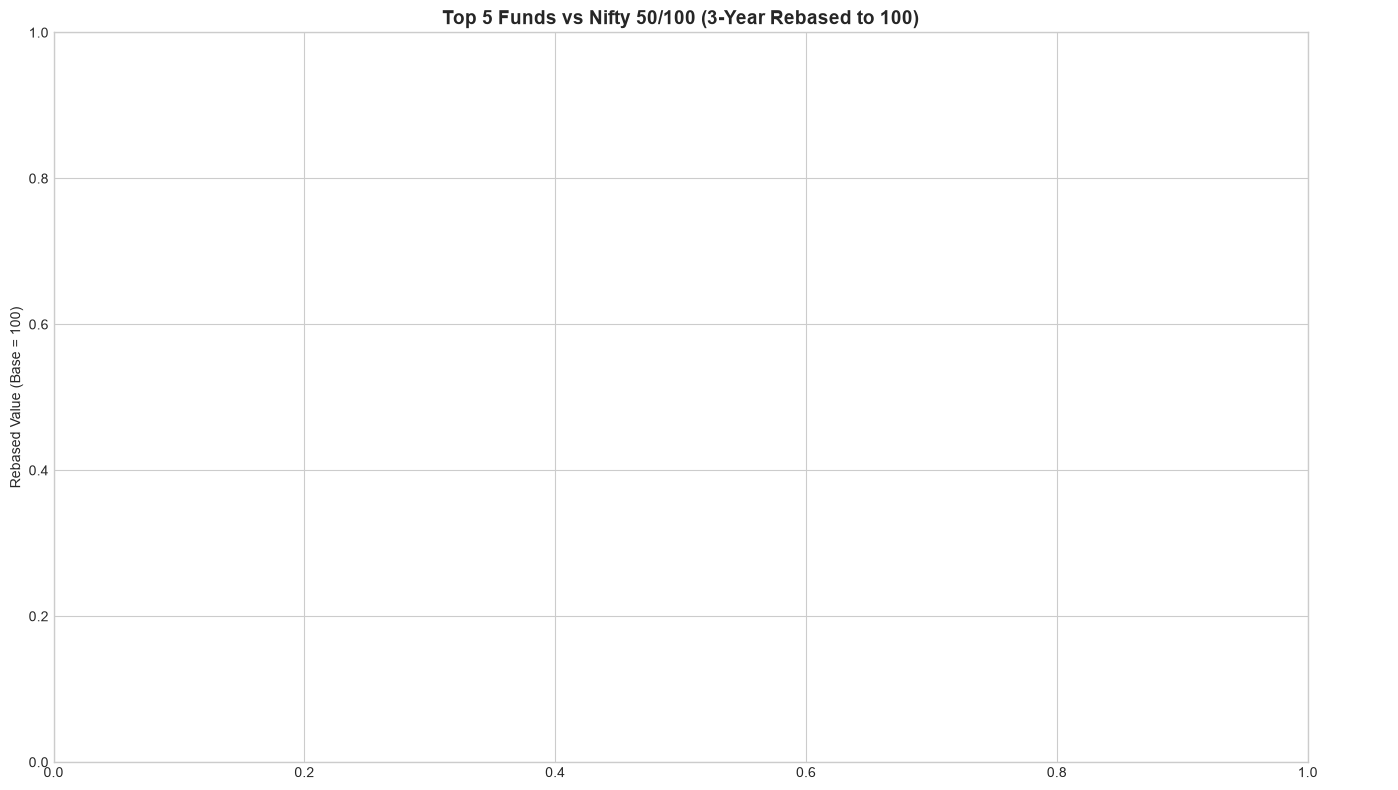


Tracking Error vs Nifty 100 (Annualized %):
Could not compute tracking error due to date mismatch in benchmark data.


In [18]:
# Get Top 5 funds from scorecard
top_5_codes = scorecard['amfi_code'].head(5).tolist()
top_5_names = scorecard.head(5)['scheme_name'].str.split(' - ').str[0].tolist()

# Get Nifty 50 and Nifty 100 from the original bench_df
nifty_50 = bench_df[bench_df['index_name'].str.contains('Nifty 50', case=False)].copy()
nifty_100 = bench_df[bench_df['index_name'].str.contains('Nifty 100', case=False)].copy()

# FORCE dates back to standard Pandas Timestamps for safe filtering
nifty_50['date'] = pd.to_datetime(nifty_50['date'])
nifty_100['date'] = pd.to_datetime(nifty_100['date'])

# Define 3-year window
start_date = max_date - pd.DateOffset(years=3)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot Benchmarks (Rebased to 100) - Safely check if empty
for bench, label in [(nifty_50, 'Nifty 50'), (nifty_100, 'Nifty 100')]:
    b_data = bench[(bench['date'] >= start_date) & (bench['date'] <= max_date)].set_index('date')
    
    if not b_data.empty and 'close' in b_data.columns:
        rebased = (b_data['close'] / b_data['close'].iloc[0]) * 100
        ax.plot(rebased.index, rebased, linestyle='--', linewidth=2, label=label)
    else:
        print(f"Not enough data to plot {label} for the selected 3-year window.")

# Plot Top 5 Funds (Rebased to 100)
tracking_errors = {}
for code, name in zip(top_5_codes, top_5_names):
    f_data = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= start_date) & (nav_df['date'] <= max_date)].set_index('date')
    
    # Safe merge for tracking error
    if not nifty_100.empty:
        f_data = f_data.join(nifty_100.set_index('date')['close'], rsuffix='_bench')
        f_data = f_data.dropna()
        
        if not f_data.empty:
            # Rebase Fund
            rebased_fund = (f_data['nav'] / f_data['nav'].iloc[0]) * 100
            ax.plot(rebased_fund.index, rebased_fund, linewidth=2, label=name)
            
            # Compute Tracking Error vs Nifty 100
            fund_ret = f_data['nav'].pct_change().dropna()
            bench_ret = f_data['close_bench'].pct_change().dropna()
            
            # Align indexes before subtracting
            common_index = fund_ret.index.intersection(bench_ret.index)
            if len(common_index) > 0:
                te = np.std(fund_ret.loc[common_index] - bench_ret.loc[common_index]) * np.sqrt(252) * 100
                tracking_errors[name] = te

ax.set_title("Top 5 Funds vs Nifty 50/100 (3-Year Rebased to 100)", fontsize=14, fontweight='bold')
ax.set_ylabel("Rebased Value (Base = 100)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save Deliverable 3
out_path_chart = os.path.join(CHART_DIR, "benchmark_comparison.png")
plt.savefig(out_path_chart, dpi=150, bbox_inches='tight')
plt.show()

# Print Tracking Errors
print("\nTracking Error vs Nifty 100 (Annualized %):")
if tracking_errors:
    te_df = pd.DataFrame(list(tracking_errors.items()), columns=['Fund', 'Tracking_Error_%'])
    print(te_df.to_string(index=False))
else:
    print("Could not compute tracking error due to date mismatch in benchmark data.")